In [14]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [15]:
Spotify_limpio = pd.read_csv('Spotify_data_total.csv')

In [16]:
Spotify_limpio.head()

,EDAD,GENERO,ANTIGUEDAD,DISPOSITIVO,SUSCRIPCION,QUIERE_PREMIUM,PREMIUM_PREFERIDO,CONTENIDO_PREFERIDO,GENERO_FAV_MUSICA,FRANJA_HORARIA,...,MOMENTO_MUSICA,DESCUBRIMIENTO,VALORACION_RECOMENDACIONES,FRECUENCIA_POD,GENERO_FAV_POD,FORMATO_PREFERIDO_POD,PREFERENCIA_PRESENTADOR_POD,PREFERENCIA_DURACION_POD,SATISFACCION_POD,CANTIDAD_DISPOSITIVOS
0,20-35,Mujer,Más de 2 años,Altavoz Inteligente,Free,Si,Family Plan-Rs 179/month,Podcast,Melody,Noche,...,Tiempo libre,Listas de reproducción,3,Diariamente,Comedia,Entrevista,Ambos,Ambos,Ok,1
1,12-20,Hombre,Más de 2 años,Ordenador,Free,Si,Individual Plan- Rs 119/ month,Podcast,Rap,Tarde,...,Entrenamiento,Listas de reproducción,2,Varias veces por semana,Comedia,Entrevista,Ambos,No aplicable/Ninguno,Satisfecho,1
2,35-60,Otro,De 6 meses a 1 año,Altavoz Inteligente,Free,Si,Student Plan-Rs 59/month,Podcast,Pop,Noche,...,"Horas de estudio, Mientras viaja",Listas de reproducción,4,Una vez por semana,Deportes,Entrevista,No aplicable/Ninguno,Ambos,Satisfecho,1
3,20-35,Mujer,De 1 año a 2 años,"Smartphone, Altavoz Inteligente",Free,No,No aplicable/Ninguno,Music,Melody,Noche,...,"Horario de oficina, Entrenamiento, Tiempo libre","Recomendaciones, Listas de reproducción",4,Nunca,No aplicable/Ninguno,No aplicable/Ninguno,No aplicable/Ninguno,No aplicable/Ninguno,Ok,2
4,20-35,Mujer,De 1 año a 2 años,Smartphone,Free,No,No aplicable/Ninguno,Music,Melody,Noche,...,Tiempo libre,"Recomendaciones, Listas de reproducción",4,Raramente,Estilo de vida y salud,Relato,Famoso,Ambos,Ok,1


In [17]:
Spotify_limpio.columns

Index(['EDAD', 'GENERO', 'ANTIGUEDAD', 'DISPOSITIVO', 'SUSCRIPCION',
       'QUIERE_PREMIUM', 'PREMIUM_PREFERIDO', 'CONTENIDO_PREFERIDO',
       'GENERO_FAV_MUSICA', 'FRANJA_HORARIA', 'ESTADO_ANIMO', 'MOMENTO_MUSICA',
       'DESCUBRIMIENTO', 'VALORACION_RECOMENDACIONES', 'FRECUENCIA_POD',
       'GENERO_FAV_POD', 'FORMATO_PREFERIDO_POD',
       'PREFERENCIA_PRESENTADOR_POD', 'PREFERENCIA_DURACION_POD',
       'SATISFACCION_POD', 'CANTIDAD_DISPOSITIVOS'],
      dtype='object')

In [18]:
Spotify_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   EDAD                         520 non-null    object
 1   GENERO                       520 non-null    object
 2   ANTIGUEDAD                   520 non-null    object
 3   DISPOSITIVO                  520 non-null    object
 4   SUSCRIPCION                  520 non-null    object
 5   QUIERE_PREMIUM               520 non-null    object
 6   PREMIUM_PREFERIDO            520 non-null    object
 7   CONTENIDO_PREFERIDO          520 non-null    object
 8   GENERO_FAV_MUSICA            520 non-null    object
 9   FRANJA_HORARIA               520 non-null    object
 10  ESTADO_ANIMO                 520 non-null    object
 11  MOMENTO_MUSICA               520 non-null    object
 12  DESCUBRIMIENTO               520 non-null    object
 13  VALORACION_RECOMENDACIONES   520 no

### Codificación de columnas multirrespuesta

In [19]:
multirrespuesta_cols = ["DISPOSITIVO", "MOMENTO_MUSICA", "DESCUBRIMIENTO", "ESTADO_ANIMO", "GENERO_FAV_POD"]

for col in multirrespuesta_cols:
    Spotify_limpio[col] = Spotify_limpio[col].str.split(", ")
    
for col in multirrespuesta_cols:
    dummies = Spotify_limpio[col].str.join('|').str.get_dummies()
    dummies = dummies.add_prefix(col + "_")
    Spotify_limpio = pd.concat([Spotify_limpio, dummies], axis=1)
    Spotify_limpio.drop(columns=[col], inplace=True)

### Codificación de la tabla completa

In [20]:
Spotify_codificado = pd.get_dummies(Spotify_limpio, drop_first=True)

In [21]:
Spotify_codificado.head()

,VALORACION_RECOMENDACIONES,CANTIDAD_DISPOSITIVOS,DISPOSITIVO_Altavoz Inteligente,DISPOSITIVO_Dispositivo Portatil Inteligente,DISPOSITIVO_Ordenador,DISPOSITIVO_Smartphone,MOMENTO_MUSICA_Aleatorio,MOMENTO_MUSICA_Antes de dormir,MOMENTO_MUSICA_Cocinando,MOMENTO_MUSICA_Entrenamiento,...,PREFERENCIA_PRESENTADOR_POD_Desconocido,PREFERENCIA_PRESENTADOR_POD_Famoso,PREFERENCIA_PRESENTADOR_POD_No aplicable/Ninguno,PREFERENCIA_DURACION_POD_Corto,PREFERENCIA_DURACION_POD_Largo,PREFERENCIA_DURACION_POD_No aplicable/Ninguno,SATISFACCION_POD_Muy insatisfecho,SATISFACCION_POD_Muy satisfecho,SATISFACCION_POD_Ok,SATISFACCION_POD_Satisfecho
0,3,1,1,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
1,2,1,0,0,1,0,0,0,0,1,...,False,False,False,False,False,True,False,False,False,True
2,4,1,1,0,0,0,0,0,0,0,...,False,False,True,False,False,False,False,False,False,True
3,4,2,1,0,0,1,0,0,0,1,...,False,False,True,False,False,True,False,False,True,False
4,4,1,0,0,0,1,0,0,0,0,...,False,True,False,False,False,False,False,False,True,False


### Definir X e Y

In [22]:
y = Spotify_codificado["QUIERE_PREMIUM_Si"]

import re
cols_excluir = [c for c in Spotify_codificado.columns
                if re.search(r"^(QUIERE_PREMIUM_|SUSCRIPCION_)", c) or c.startswith("PREMIUM_")]

X = Spotify_codificado.drop(columns=cols_excluir, errors="ignore")


### Train y Test división. Entrenamiento del modelo

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [24]:
pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=False)), 
    ("lr", LogisticRegression(max_iter=5000, class_weight="balanced"))
])
pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,False
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


### Evaluación

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

pred = pipe.predict(X_test)
proba = pipe.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))

[[53 30]
 [15 32]]
              precision    recall  f1-score   support

       False       0.78      0.64      0.70        83
        True       0.52      0.68      0.59        47

    accuracy                           0.65       130
   macro avg       0.65      0.66      0.64       130
weighted avg       0.68      0.65      0.66       130

ROC-AUC: 0.7187900538323507


### Variables más influyentes

In [27]:
import numpy as np
import pandas as pd

lr = pipe.named_steps["lr"]
coef = pd.Series(lr.coef_[0], index=X.columns).sort_values()

# odds ratios
odds = np.exp(coef)

res = pd.DataFrame({
    "coef": coef,
    "odds_ratio": odds
})

print("Top + (aumentan QUIERE_PREMIUM):")
print(res.tail(15))

print("\nTop - (reducen QUIERE_PREMIUM):")
print(res.head(15))

Top + (aumentan QUIERE_PREMIUM):
                                          coef  odds_ratio
MOMENTO_MUSICA_Mientras viaja         0.256305    1.292146
GENERO_FAV_POD_Tecnología             0.261514    1.298895
MOMENTO_MUSICA_Antes de dormir        0.269931    1.309874
CONTENIDO_PREFERIDO_Podcast           0.277881    1.320329
GENERO_FAV_POD_Actualidad             0.280186    1.323376
GENERO_FAV_POD_Finanzas y actualidad  0.299049    1.348576
PREFERENCIA_DURACION_POD_Largo        0.303409    1.354468
GENERO_FAV_POD_Comedia                0.307251    1.359683
MOMENTO_MUSICA_Horas de estudio       0.309499    1.362742
GENERO_FAV_MUSICA_Rap                 0.317510    1.373703
ESTADO_ANIMO_Tristeza                 0.344340    1.411058
FRECUENCIA_POD_Una vez por semana     0.359496    1.432607
FORMATO_PREFERIDO_POD_Educativo       0.367286    1.443811
FRECUENCIA_POD_Raramente              0.438895    1.550992
FRECUENCIA_POD_Nunca                  0.639726    1.895962

Top - (reducen QUIERE_

### Visualización de las variables más importantes

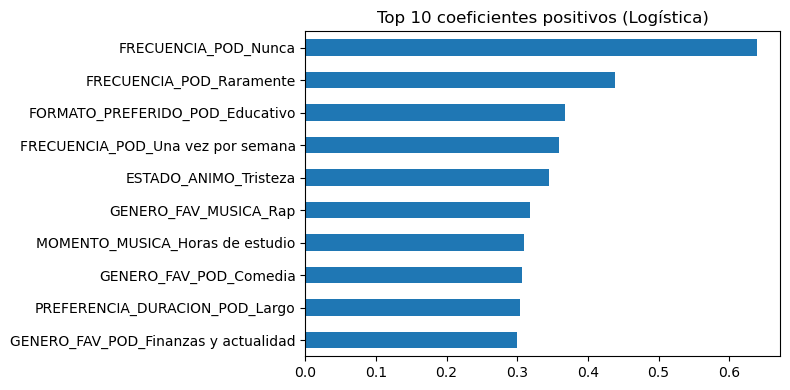

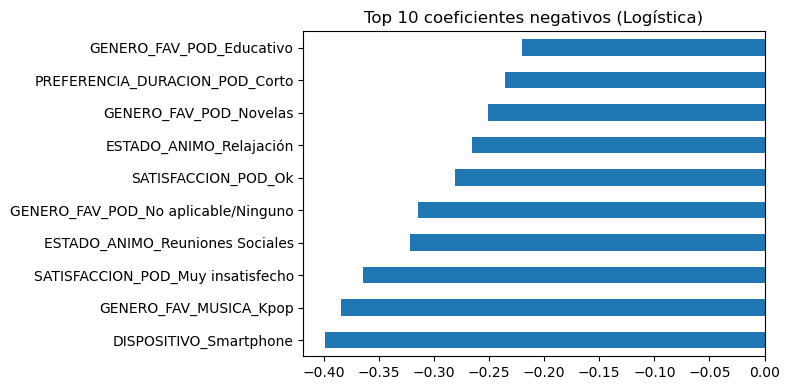

In [29]:
top_pos = res.tail(10)
top_neg = res.head(10)

plt.figure(figsize=(8,4))
top_pos["coef"].plot(kind="barh")
plt.title("Top 10 coeficientes positivos (Logística)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
top_neg["coef"].plot(kind="barh")
plt.title("Top 10 coeficientes negativos (Logística)")
plt.tight_layout()
plt.show()

1) Lo que dicen tus números (en cristiano)
Matriz de confusión
[[53 30]
 [15 32]]

Si tomamos True = quiere premium (1) y False = no quiere premium (0):

TN = 53 → predijo “No” y era “No”

FP = 30 → predijo “Sí” pero era “No”

FN = 15 → predijo “No” pero era “Sí”

TP = 32 → predijo “Sí” y era “Sí”

Esto significa:

El modelo detecta bastantes “Sí” (TP=31), pero también se confunde bastante con falsos positivos (FP=29).

Clase False

Aquí “False” = no quiere Premium

precision = 0.78
De todos los que el modelo dijo que eran False, el 78% realmente lo eran.

recall = 0.64
De todos los que realmente eran False, el modelo detectó el 64%.

f1-score = 0.70
Es un equilibrio entre precision y recall. Para esta clase está bastante decente.

Clase True

Aquí “True” = sí quiere Premium

precision = 0.52
De todos los que el modelo predijo como True, solo el 52% realmente quería Premium.

O sea: cuando el modelo dice “sí quiere Premium”, falla bastante.

recall = 0.68
De todos los que realmente querían Premium, el modelo detectó el 68%.

Esto está mejor: el modelo sí encuentra bastante bien a los que quieren Premium.

f1-score = 0.59
Es más flojo que en la clase False, pero aceptable para un dataset como el tuyo.